In [1]:
import numpy as np 
import matplotlib.pyplot as plt


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

/home/lcmj2803/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/lcmj2803/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [33]:
from scipy.signal import spectrogram

In [3]:
#reproducibilidad 
SEED = 1234
rng = np.random.default_rng(SEED)

In [4]:
def awgn(x:np.ndarray, snr_db:float,rng_local = None) -> np.ndarray:
    if rng_local is None:
        rng_local = np.random.default_rng()
    
    #Potenci promedio 
    p_sig = np.mean(np.abs(x)**2)
    snr_lin = 10 **(snr_db/10)
    
    #Potencia de ruido necesaria 
    p_noise = p_sig / snr_lin
    
    #Ruido complejo 
    noise = (rng_local.normal(0, np.sqrt(p_noise/2), x.shape) +
             1j*rng_local.normal(0, np.sqrt(p_noise/2), size = x.shape))
    
    return (x + noise).astype(np.complex64)

In [5]:
def rect_pulse_upsample(symbols:np.ndarray, sps:int) -> np.ndarray:
    x = np.repeat(symbols, repeat=sps)
    return x.astype(np.complex64)

In [6]:
def iq_to_array(xc:np.ndarray) -> np.ndarray:
    return np.stack((xc.real, xc.imag), axis=-1).astype(np.float32)

In [11]:
#Parametros Globales 
SPS = 4
T_list = [256,512,1024,2048]
SNR_GRID = np.arange(15,31,5)
N_PER_ORDER_SNR_FSK = 950
ORDERS_FSK = [2,4,8,16,32]
T_max_fsk = max(T_list) 

In [12]:
N_theoretical = len(ORDERS_FSK) * len(SNR_GRID) * N_PER_ORDER_SNR_FSK * len(T_list)
print("N_theoretical =", N_theoretical)


N_theoretical = 76000


In [13]:
def make_clip_fsk(M:int, T:int, sps:int, snr_db:float, rng_local=None) -> np.ndarray:
    """
    Genera un clip FSK con M-ary FSK:
      - M: orden FSK (2,4,6,8,16,32)
      - T: longitud total en muestras
      - sps: muestras por símbolo
      - snr_db: SNR del canal AWGN

    Retorna: vector complejo de longitud T.
    """
    if rng_local is None:
        rng_local = rng

    # Número de símbolos necesarios para cubrir T muestras
    nsym = int(np.ceil(T / sps))

    # Símbolos FSK (índices de 0 a M-1)
    sym_idx = rng_local.integers(0, M, size=nsym)

    # Tiempo discreto dentro de un símbolo
    n = np.arange(sps)

    # Definimos M frecuencias distintas, separadas de forma uniforme.
    # Frecuencias normalizadas (ciclos por muestra).
    k = np.arange(M)
    # Por ejemplo, de 0.5/sps hasta (M+0.5)/sps. Ajustable si quieres más separación.
    freqs = (k + 0.5) / sps   # [ciclos/muestra]

    # Tabla de tonos: shape = (M, sps)
    tone_table = np.exp(1j * 2 * np.pi * freqs[:, None] * n[None, :]).astype(np.complex64)

    # Construimos la señal uniendo los tonos de cada símbolo
    x = tone_table[sym_idx].reshape(-1)   # (nsym * sps, )

    # Recorte / padding a T muestras
    if len(x) < T:
        x = np.pad(x, (0, T - len(x)))
    else:
        x = x[:T]

    # Canal AWGN (reutiliza tu función awgn)
    xr = awgn(x, snr_db=snr_db, rng_local=rng_local)
    return xr.astype(np.complex64)


In [14]:
clips_fsk   = []
orders_fsk  = []
snrs_fsk    = []
Ts_used_fsk = []

for T_ in T_list:
    print(f"Generando FSK para T = {T_}...")
    for M in ORDERS_FSK:
        for snr_db in SNR_GRID:
            for _ in range(N_PER_ORDER_SNR_FSK):
                xc = make_clip_fsk(
                    M       = M,
                    T       = T_,
                    sps     = SPS,   # reutiliza SPS de QAM
                    snr_db  = snr_db,
                    rng_local = rng
                )

                # IQ (T_, 2)
                x_arr = iq_to_array(xc)

                # padding a T_max_fsk
                if T_ < T_max_fsk:
                    x_pad = np.zeros((T_max_fsk, 2), dtype=np.float32)
                    x_pad[:T_, :] = x_arr
                else:
                    x_pad = x_arr

                clips_fsk.append(x_pad)
                orders_fsk.append(M)
                snrs_fsk.append(snr_db)
                Ts_used_fsk.append(T_)

# Listas -> arrays
X_fsk       = np.stack(clips_fsk, axis=0)             # (N_total_fsk, T_max_fsk, 2)
y_order_fsk = np.array(orders_fsk, dtype=np.int16)    # orden FSK
snr_fsk     = np.array(snrs_fsk,   dtype=np.float32)
T_used_fsk  = np.array(Ts_used_fsk, dtype=np.int16)

print("X_fsk.shape     =", X_fsk.shape)
print("N_total_fsk     =", X_fsk.shape[0])
print("órdenes únicos  :", np.unique(y_order_fsk))
print("SNR únicas      :", np.unique(snr_fsk))
print("T únicos        :", np.unique(T_used_fsk))


Generando FSK para T = 256...
Generando FSK para T = 512...
Generando FSK para T = 1024...
Generando FSK para T = 2048...
X_fsk.shape     = (76000, 2048, 2)
N_total_fsk     = 76000
órdenes únicos  : [ 2  4  8 16 32]
SNR únicas      : [15. 20. 25. 30.]
T únicos        : [ 256  512 1024 2048]


In [15]:
def plot_constellation_fsk_full(xc, title=""):
    # muchas muestras, no una por símbolo
    x_plot = xc
    plt.figure(figsize=(4,4))
    plt.scatter(x_plot.real, x_plot.imag, s=1, alpha=0.3)
    plt.axhline(0); plt.axvline(0)
    plt.title(title)
    plt.xlabel("I"); plt.ylabel("Q")
    plt.grid(True)
    plt.show()

    

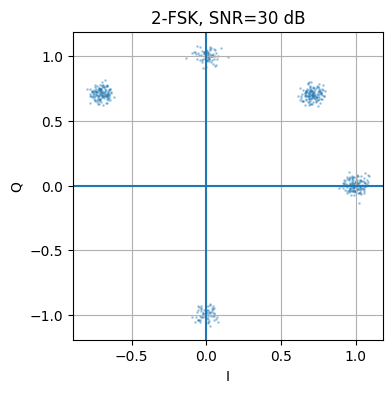

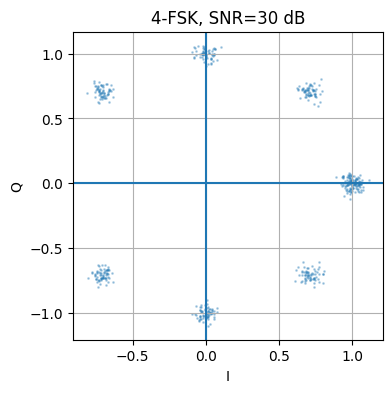

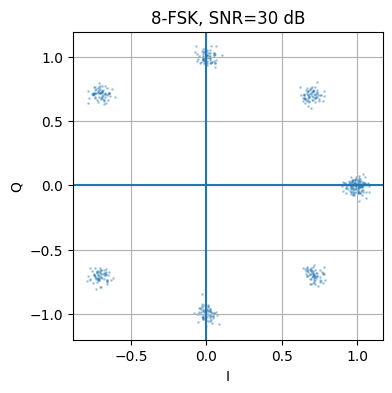

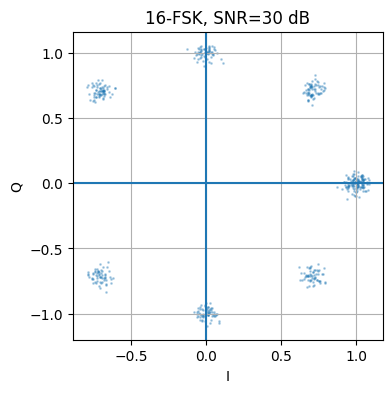

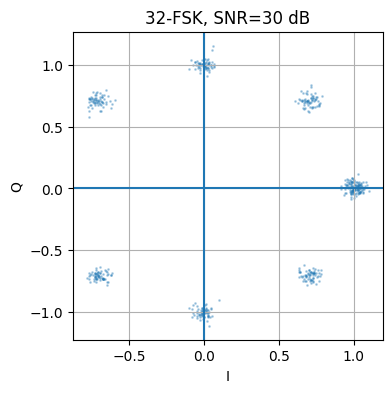

In [16]:
for M in ORDERS_FSK:
    xc = make_clip_fsk(M=M, T=512, sps=SPS, snr_db=25, rng_local=rng)
    plot_constellation_fsk_full(xc, title=f"{M}-FSK, SNR={snr_db} dB")


In [17]:
def cumulants_features(x):
    x = x - np.mean(x)
    C20 = np.mean(x**2)
    C21 = np.mean(np.abs(x)**2)
    C40 = np.mean(x**4) - 3*(np.mean(x**2)**2)
    C41 = np.mean(np.abs(x)**2 * x**2) - 2*np.mean(x**2)*np.mean(np.abs(x)**2)
    C42 = (np.mean(np.abs(x)**4)
           - (np.mean(np.abs(x)**2)**2)
           - 2*(np.abs(np.mean(x**2))**2))
    return np.array([
        C20.real, C20.imag,
        C21,
        C40.real, C40.imag,
        C41.real, C41.imag,
        C42
    ])


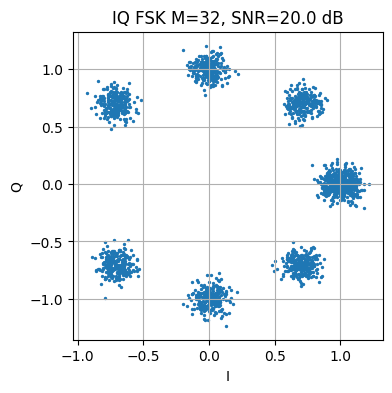

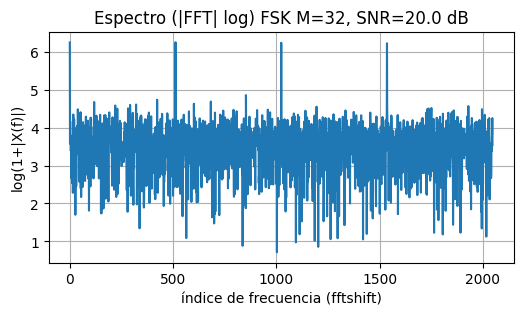

Cumulantes FSK ejemplo (C20.real, C20.imag, C21, C40.real, C40.imag, C41.real, C41.imag, C42):
[-0.05841735  0.00096638  0.9444203  -0.26623678  0.0204332   0.03951343
  0.00224994  0.12237755]


In [36]:
# ==========================================
# 4) EJEMPLO: IQ, ESPECTRO Y CUMULANTES FSK
# ==========================================

# Elegimos un clip de ejemplo: por ejemplo M=32, T_max_fsk, snr=20 dB
M_example   = 32
T_example   = T_max_fsk
snr_example = 20.0

xc_ex = make_clip_fsk(M_example, T_example, SPS, snr_example, rng_local=rng)
iq_ex = iq_to_array(xc_ex)

# 4.1 IQ
plt.figure(figsize=(4, 4))
plt.scatter(iq_ex[:, 0], iq_ex[:, 1], s=2)
plt.title(f"IQ FSK M={M_example}, SNR={snr_example} dB")
plt.xlabel("I")
plt.ylabel("Q")
plt.grid(True)
plt.show()

# 4.2 ESPECTRO
Xf_ex   = np.fft.fftshift(np.fft.fft(xc_ex))
mag_log = np.log1p(np.abs(Xf_ex))

plt.figure(figsize=(6, 3))
plt.plot(mag_log)
plt.title(f"Espectro (|FFT| log) FSK M={M_example}, SNR={snr_example} dB")
plt.xlabel("índice de frecuencia (fftshift)")
plt.ylabel("log(1+|X(f)|)")
plt.grid(True)
plt.show()

# 4.3 CUMULANTES
cum_ex = cumulants_features(xc_ex)
print("Cumulantes FSK ejemplo (C20.real, C20.imag, C21, C40.real, C40.imag, C41.real, C41.imag, C42):")
print(cum_ex)

In [20]:
# ===============================
# Guardar dataset FSK en .npz
# ===============================

save_path = "/home/lcmj2803/modelo_modulacion/esquemas_mods/FSK"   # cámbialo si quieres guardarlo localmente

np.savez_compressed(
    save_path,
    X=X_fsk.astype(np.float32),         # (N, T_max, 2)
    y_order=y_order_fsk.astype(np.int16),
    snr=snr_fsk.astype(np.float32),
    T_used=T_used_fsk.astype(np.int16),
    modulation="FSK"
)

print("Dataset FSK guardado en:", save_path)
print("X_fsk.shape:", X_fsk.shape)
print("Órdenes únicos:", np.unique(y_order_fsk))
print("SNR únicos:", np.unique(snr_fsk))
print("T usados:", np.unique(T_used_fsk))


Dataset FSK guardado en: /home/lcmj2803/modelo_modulacion/esquemas_mods/FSK
X_fsk.shape: (76000, 2048, 2)
Órdenes únicos: [ 2  4  8 16 32]
SNR únicos: [15. 20. 25. 30.]
T usados: [ 256  512 1024 2048]


In [21]:
data = np.load("/home/lcmj2803/modelo_modulacion/esquemas_mods/fsk/FSK.npz", allow_pickle=True)

X_fsk       = data["X"]
y_order_fsk = data["y_order"]
snr_fsk     = data["snr"]
T_used_fsk  = data["T_used"]
modType     = data["modulation"].item()

print("Modulación:", modType)
print("X shape:", X_fsk.shape)


Modulación: FSK
X shape: (76000, 2048, 2)


In [22]:
N_fsk, T_max_fsk, C = X_fsk.shape
assert C == 2

In [23]:
# 1) IQ aplanado
X_iq_fsk = X_fsk.reshape(N_fsk, -1)

# 2) Compleja
X_complex_fsk = X_fsk[...,0] + 1j * X_fsk[...,1]


In [24]:
def compute_spectrum_batched(X_complex, batch_size=500):
    N = X_complex.shape[0]
    out = np.zeros_like(X_complex, dtype=np.float32)

    for i in range(0, N, batch_size):
        xb = X_complex[i:i+batch_size]
        Xf = np.fft.fftshift(np.fft.fft(xb, axis=1), axes=1)
        out[i:i+batch_size] = np.log1p(np.abs(Xf))
    return out


In [29]:
X_spec_fsk = compute_spectrum_batched(X_complex_fsk, batch_size=300)
X_spec_fsk = X_spec_fsk.reshape(N_fsk, -1)


In [30]:
# 2.4 Cumulantes
def cumulants_features(x):
    x = x - np.mean(x)
    C20 = np.mean(x**2)
    C21 = np.mean(np.abs(x)**2)
    C40 = np.mean(x**4) - 3*(np.mean(x**2)**2)
    C41 = np.mean(np.abs(x)**2 * x**2) - 2*np.mean(x**2)*np.mean(np.abs(x)**2)
    C42 = (np.mean(np.abs(x)**4)
           - (np.mean(np.abs(x)**2)**2)
           - 2*(np.abs(np.mean(x**2))**2))
    return np.array([
        C20.real, C20.imag,
        C21,
        C40.real, C40.imag,
        C41.real, C41.imag,
        C42
    ], dtype=np.float32)

X_cum_fsk = np.array([cumulants_features(sig) for sig in X_complex_fsk])
print("X_cum_fsk.shape:", X_cum_fsk.shape)  # (N, 8)

# Codificar etiquetas (0..K-1) si hace falta
le_fsk = LabelEncoder()
y_fsk  = le_fsk.fit_transform(y_order_fsk)
classes_fsk = le_fsk.classes_
print("Órdenes FSK:", classes_fsk)

X_cum_fsk.shape: (76000, 8)
Órdenes FSK: [ 2  4  8 16 32]


In [26]:
# Fusión 1: IQ + Cumulantes
X_fusion_iq_cum_fsk = np.hstack([X_iq_fsk, X_cum_fsk])
print("X_fusion_iq_cum_fsk.shape:", X_fusion_iq_cum_fsk.shape)

del X_fusion_iq_cum_fsk
import gc; gc.collect()


X_fusion_iq_cum_fsk.shape: (76000, 4104)


65

In [31]:
X_fusion_spec_cum_fsk = np.hstack([X_spec_fsk, X_cum_fsk])
print("X_fusion_spec_cum_fsk:", X_fusion_spec_cum_fsk.shape)

# baseline/modelo

del X_fusion_spec_cum_fsk
import gc; gc.collect()



X_fusion_spec_cum_fsk: (76000, 2056)


96

In [32]:
# Fusión 3: IQ + Espectro + Cumulantes
X_fusion_all_fsk = np.hstack([X_iq_fsk, X_spec_fsk, X_cum_fsk])
print("X_fusion_all_fsk.shape:", X_fusion_all_fsk.shape)

X_fusion_all_fsk.shape: (76000, 6152)


/tmp/ipykernel_10537/2029372016.py:13: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Sxx = spectrogram(


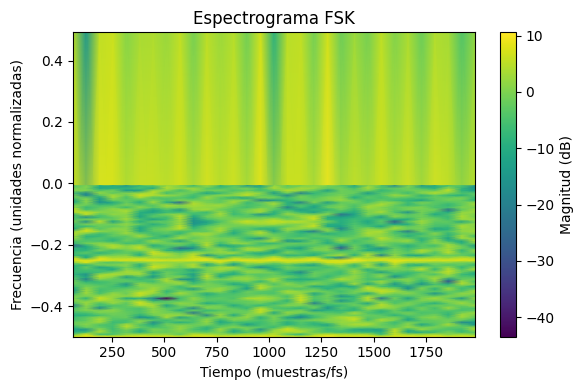

In [37]:
def compute_spectrogram(xc, fs=1.0, nperseg=128, noverlap=64):
    """
    xc : señal compleja 1D (np.ndarray)
    fs : frecuencia de muestreo (puedes usar 1.0 si estás en unidades normalizadas)
    nperseg : tamaño de ventana de la STFT
    noverlap: solapamiento entre ventanas

    Devuelve:
        f   : vector de frecuencias
        t   : vector de tiempos
        Sdb : espectrograma en dB (matriz [len(f), len(t)])
    """
    f, t, Sxx = spectrogram(
        xc,
        fs=fs,
        window='hann',
        nperseg=nperseg,
        noverlap=noverlap,
        scaling='density',
        mode='magnitude'
    )
    Sdb = 20 * np.log10(Sxx + 1e-12)   # pasar a dB y evitar log(0)
    return f, t, Sdb

# ===== Ejemplo con un clip FSK =====
# xc_ex es tu clip complejo, por ejemplo:
xc_ex = make_clip_fsk(M_example, T_example, SPS, snr_example, rng_local=rng)

fs = 1.0  # si no tienes frecuencia real, déjalo en 1.0 (unidades normalizadas)
f, t, Sdb = compute_spectrogram(xc_ex, fs=fs, nperseg=128, noverlap=64)

plt.figure(figsize=(6,4))
plt.pcolormesh(t, f, Sdb, shading='gouraud')
plt.ylabel('Frecuencia (unidades normalizadas)')
plt.xlabel('Tiempo (muestras/fs)')
plt.title('Espectrograma FSK')
plt.colorbar(label='Magnitud (dB)')
plt.tight_layout()
plt.show()


In [ ]:
""" 


 Elegimos un clip de ejemplo: por ejemplo M=32, T_max_fsk, snr=20 dB
M_example   = 32
T_example   = T_max_fsk
snr_example = 20.0

xc_ex = make_clip_fsk(M_example, T_example, SPS, snr_example, rng_local=rng)
iq_ex = iq_to_array(xc_ex)

# 4.1 IQ
plt.figure(figsize=(4, 4))
plt.scatter(iq_ex[:, 0], iq_ex[:, 1], s=2)
plt.title(f"IQ FSK M={M_example}, SNR={snr_example} dB")
plt.xlabel("I")
plt.ylabel("Q")
plt.grid(True)
plt.show()

# 4.2 ESPECTRO
Xf_ex   = np.fft.fftshift(np.fft.fft(xc_ex))
mag_log = np.log1p(np.abs(Xf_ex))

plt.figure(figsize=(6, 3))
plt.plot(mag_log)
plt.title(f"Espectro (|FFT| log) FSK M={M_example}, SNR={snr_example} dB")
plt.xlabel("índice de frecuencia (fftshift)")
plt.ylabel("log(1+|X(f)|)")
plt.grid(True)
plt.show()

# 4.3 CUMULANTES
cum_ex = cumulants_features(xc_ex)
print("Cumulantes FSK ejemplo (C20.real, C20.imag, C21, C40.real, C40.imag, C41.real, C41.imag, C42):")
print(cum_ex)


"""